# Levi Project — AI-Powered Spam Email Detection System
### Binary Classification Pipeline — Support Vector Machine (SVM) + TF-IDF
---
**Dataset:** Gaggle Dataset  
**Labels:** `0` = Ham Email &nbsp;|&nbsp; `1` = Spam Email  
**Pipeline:** Raw Data → Cleanup → Pre-processing → Vectorization → Training → Prediction

---
## STAGE 1: Raw Data Acquisition

In [1]:
# ============================================================
# STAGE 1 — Step 1: Load the Dataset
# - Import pandas for data manipulation
# - Load LEVI_DATASET.csv from the current directory
# - Combine 'subject' and 'body' columns into one 'email_text' column
#   (email_text = subject + body as specified in the pipeline)
# - Retain only the 'email_text' and 'label' columns
# - Display the first few records
# ============================================================

import os
import pandas as pd

# Automatic path detection — works on any computer
BASE_DIR = os.getcwd()
data_path = os.path.join(BASE_DIR, 'LEVI_DATASET.csv')

# Load the LEVI_DATASET CSV file
raw_df = pd.read_csv(data_path)

# Combine 'subject' and 'body' into a single 'email_text' column
raw_df['email_text'] = raw_df['subject'].fillna('') + ' ' + raw_df['body'].fillna('')

# Keep only the two columns needed for the ML pipeline
df = raw_df[['email_text', 'label']].copy()

# Display the first few records
df.head()

,email_text,label
0,"Never agree to be a loser Buck up, your troubl...",1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1


In [2]:
# ============================================================
# STAGE 1 — Step 2: Display Dataset Information
# - Shows column names, non-null counts, and data types
# - Helps confirm the dataset loaded correctly
# ============================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39154 entries, 0 to 39153
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   email_text  39154 non-null  object
 1   label       39154 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 611.9+ KB


In [3]:
# ============================================================
# STAGE 1 — Step 3: Display Missing Values
# - Count null/NaN entries per column
# - Identifies how many records need to be dropped or handled
# ============================================================

df.isnull().sum()

email_text    0
label         0
dtype: int64

In [4]:
# ============================================================
# STAGE 1 — Step 4: Display Class Distribution
# - Shows how many emails belong to each class
# - 0 = Ham Email
# - 1 = Spam Email
# ============================================================

class_counts = df['label'].value_counts()
class_labels = {0: 'Ham Email', 1: 'Spam Email'}

print("Class Distribution:")
for label, count in class_counts.items():
    print(f"  {class_labels[label]} (label={label}): {count} emails")

class_counts

Class Distribution:
  Spam Email (label=1): 21842 emails
  Ham Email (label=0): 17312 emails


label
1    21842
0    17312
Name: count, dtype: int64

---
## STAGE 2: Text Extraction and Cleanup

In [5]:
# ============================================================
# STAGE 2 — Step 1: Remove Duplicate Emails
# - Drop rows where email_text is an exact repetition
# - Duplicates add bias during model training
# - Reset the index after dropping so it stays sequential
# ============================================================

count_before = len(df)

# Drop duplicate email_text entries; keep the first occurrence
df = df.drop_duplicates(subset=['email_text'])
df = df.reset_index(drop=True)

count_after = len(df)

print(f"Records before removing duplicates : {count_before}")
print(f"Duplicate rows removed             : {count_before - count_after}")
print(f"Records remaining                  : {count_after}")

df.head()

Records before removing duplicates : 39154
Duplicate rows removed             : 0
Records remaining                  : 39154


,email_text,label
0,"Never agree to be a loser Buck up, your troubl...",1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1


In [6]:
# ============================================================
# STAGE 2 — Step 2: Remove Missing Values
# - Drop any row where email_text or label is null/NaN
# - Missing text cannot be classified; missing labels cannot train the model
# - Reset the index after dropping
# ============================================================

count_before = len(df)

# Drop rows with null values in email_text or label
df = df.dropna(subset=['email_text', 'label'])
df = df.reset_index(drop=True)

count_after = len(df)

print(f"Records before removing nulls : {count_before}")
print(f"Null rows removed             : {count_before - count_after}")
print(f"Records remaining             : {count_after}")

df.head()

Records before removing nulls : 39154
Null rows removed             : 0
Records remaining             : 39154


,email_text,label
0,"Never agree to be a loser Buck up, your troubl...",1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1


In [7]:
# ============================================================
# STAGE 2 — Step 3: Remove HTML Tags
# - Spam emails often embed HTML formatting
# - Tags like <div>, <a href=...>, <br>, <p> carry no text meaning
# - Uses regular expressions to detect and strip HTML patterns
# ============================================================

import re

def remove_html_tags(text):
    # Match any content enclosed in < > angle brackets (HTML tags)
    pattern = re.compile(r'<[^>]+>')
    return pattern.sub(' ', str(text))

# Apply to the email_text column
df['email_text'] = df['email_text'].apply(remove_html_tags)

print("HTML tags removed from email_text.")
df.head()

HTML tags removed from email_text.


,email_text,label
0,"Never agree to be a loser Buck up, your troubl...",1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1


In [8]:
# ============================================================
# STAGE 2 — Step 4: Remove URLs
# - Spam emails frequently contain suspicious links
# - URLs (http, https, www) are not useful word features for TF-IDF
# - Removes patterns starting with http/https or www
# ============================================================

import re

def remove_urls(text):
    # Match http/https URLs and www-prefixed links4
    pattern = re.compile(r'https?://\S+|www\.\S+')
    return pattern.sub(' ', str(text))

# Apply to the email_text column
df['email_text'] = df['email_text'].apply(remove_urls)

print("URLs removed from email_text.")
df.head()

URLs removed from email_text.


,email_text,label
0,"Never agree to be a loser Buck up, your troubl...",1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1


In [9]:
# ============================================================
# STAGE 2 — Step 5: Remove Email Addresses
# - Sender and recipient addresses within the body are not content words
# - Detects patterns like user@example.com and removes them
# ============================================================

import re

def remove_email_addresses(text):
    # Match standard email format: localpart@domain.extension
    pattern = re.compile(r'\b[\w.+-]+@[\w.-]+\.\w+\b')
    return pattern.sub(' ', str(text))

# Apply to the email_text column
df['email_text'] = df['email_text'].apply(remove_email_addresses)

print("Email addresses removed from email_text.")
df.head()

Email addresses removed from email_text.


,email_text,label
0,"Never agree to be a loser Buck up, your troubl...",1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1
2,CNN.com Daily Top 10 >+=+=+=+=+=+=+=+=+=+=+=+=...,1
3,Re: svn commit: r619753 - in /spamassassin/tru...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1


In [10]:
# ============================================================
# STAGE 2 — Step 6: Remove Punctuation
# - Characters like . , ! ? ; : " ' ( ) add noise to text
# - Removing them ensures cleaner word tokens
# - Replaces punctuation with a space to avoid merging adjacent words
# ============================================================

import re

def remove_punctuation(text):
    # Match any character that is NOT a word character (letter/digit/_) or whitespace
    pattern = re.compile(r'[^\w\s]')
    return pattern.sub(' ', str(text))

# Apply to the email_text column
df['email_text'] = df['email_text'].apply(remove_punctuation)

print("Punctuation removed from email_text.")
df.head()

Punctuation removed from email_text.


,email_text,label
0,Never agree to be a loser Buck up your troubl...,1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1
2,CNN com Daily Top 10 ...,1
3,Re svn commit r619753 in spamassassin tru...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1


In [11]:
# ============================================================
# STAGE 2 — Step 7: Remove Numbers
# - Digits and numeric sequences are generally not meaningful text features
# - Removes standalone numbers and sequences of digits
# ============================================================

import re

def remove_numbers(text):
    # Match one or more consecutive digit characters
    pattern = re.compile(r'\d+')
    return pattern.sub(' ', str(text))

# Apply to the email_text column
df['email_text'] = df['email_text'].apply(remove_numbers)

print("Numbers removed from email_text.")
df.head()

Numbers removed from email_text.


,email_text,label
0,Never agree to be a loser Buck up your troubl...,1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1
2,CNN com Daily Top ...,1
3,Re svn commit r in spamassassin trunk l...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1


In [12]:
# ============================================================
# STAGE 2 — Step 8: Remove Special Unnecessary Characters
# - Characters like _ = + | # ~ ^ \ / remain after earlier steps
# - Retains ONLY alphabetic letters (a-z, A-Z) and whitespace
# - This produces a clean alphabetic-only text
# ============================================================

import re

def remove_special_characters(text):
    # Keep only alphabetic letters and whitespace; replace everything else
    pattern = re.compile(r'[^a-zA-Z\s]')
    return pattern.sub(' ', str(text))

# Apply to the email_text column
df['email_text'] = df['email_text'].apply(remove_special_characters)

print("Special characters removed from email_text.")
df.head()

Special characters removed from email_text.


,email_text,label
0,Never agree to be a loser Buck up your troubl...,1
1,Befriend Jenna Jameson \nUpgrade your sex and ...,1
2,CNN com Daily Top ...,1
3,Re svn commit r in spamassassin trunk l...,0
4,SpecialPricesPharmMoreinfo \nWelcomeFastShippi...,1


In [13]:
# ============================================================
# STAGE 2 — Step 9: Remove Extra Whitespace
# - Previous cleanup steps may leave multiple consecutive spaces
# - Collapse all multi-space sequences into a single space
# - Strip leading and trailing spaces from each email
# ============================================================

import re

def remove_extra_whitespace(text):
    # Replace one or more whitespace characters with a single space
    text = re.sub(r'\s+', ' ', str(text))
    # Remove leading and trailing spaces
    return text.strip()

# Apply to the email_text column
df['email_text'] = df['email_text'].apply(remove_extra_whitespace)

print("Extra whitespace removed from email_text.")
print(f"Total clean records: {len(df)}")
df.head()

Extra whitespace removed from email_text.
Total clean records: 39154


,email_text,label
0,Never agree to be a loser Buck up your trouble...,1
1,Befriend Jenna Jameson Upgrade your sex and pl...,1
2,CNN com Daily Top THE DAILY TOP from CNN com T...,1
3,Re svn commit r in spamassassin trunk lib Mail...,0
4,SpecialPricesPharmMoreinfo WelcomeFastShipping...,1


---
## STAGE 3: Text Pre-processing

In [14]:
# ============================================================
# STAGE 3 — Step 1: Convert Text to Lowercase
# - Ensures 'Email', 'EMAIL', and 'email' are treated as the same word
# - Prevents case-based duplicates in the vocabulary
# ============================================================

# Convert all characters in email_text to lowercase
df['email_text'] = df['email_text'].str.lower()

print("All email text converted to lowercase.")
df.head()

All email text converted to lowercase.


,email_text,label
0,never agree to be a loser buck up your trouble...,1
1,befriend jenna jameson upgrade your sex and pl...,1
2,cnn com daily top the daily top from cnn com t...,1
3,re svn commit r in spamassassin trunk lib mail...,0
4,specialpricespharmmoreinfo welcomefastshipping...,1


In [15]:
# ============================================================
# STAGE 3 — Pre-requisite: Install and Verify NLTK
# - NLTK must be installed in the SAME Python environment
#   that this Jupyter kernel is running (tf_env / Python 3.10)
# - Uses sys.executable so pip targets the correct environment
# - Also pre-downloads all NLTK corpora needed by this pipeline
# Note: run this cell once before proceeding
# ============================================================

import sys

# Install NLTK into the active Jupyter kernel environment
!{sys.executable} -m pip install nltk --quiet

# Import NLTK and pre-download all corpora used in this notebook
import nltk
nltk.download('stopwords',                  quiet=True)
nltk.download('punkt',                      quiet=True)
nltk.download('punkt_tab',                  quiet=True)
nltk.download('wordnet',                    quiet=True)
nltk.download('omw-1.4',                    quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

print(f"NLTK {nltk.__version__} ready. All corpora downloaded.")

NLTK 3.10.0 ready. All corpora downloaded.


In [16]:
# ============================================================
# STAGE 3 — Step 2: Remove Stop Words
# - Stop words are common English words: 'the', 'is', 'in', 'and', etc.
# - They appear in almost every email and carry no discriminative value
# - Uses NLTK's built-in English stop word corpus
# Note: nltk.download may take a moment on first use
# ============================================================

# Import NLTK for Natural Language Processing utilities
import nltk

# Download the stop words corpus (only needed once per environment)
nltk.download('stopwords', quiet=True)

from nltk.corpus import stopwords

# Build the English stop word set for fast lookup
stop_words = set(stopwords.words('english'))

def remove_stop_words(text):
    # Split text into individual words, filter out stop words, rejoin
    words = text.split()
    filtered = [word for word in words if word not in stop_words]
    return ' '.join(filtered)

# Apply to the email_text column
df['email_text'] = df['email_text'].apply(remove_stop_words)

print(f"Stop words removed. Sample stop words: {list(stop_words)[:10]}")
df.head()

Stop words removed. Sample stop words: ['m', "hadn't", 'y', "hasn't", "we've", 'was', 'there', 'haven', 'than', 'it']


,email_text,label
0,never agree loser buck troubles caused small d...,1
1,befriend jenna jameson upgrade sex pleasures t...,1
2,cnn com daily top daily top cnn com top videos...,1
3,svn commit r spamassassin trunk lib mail spama...,0
4,specialpricespharmmoreinfo welcomefastshipping...,1


In [17]:
# ============================================================
# STAGE 3 — Step 3: Remove Frequent Words
# - Words that appear across almost every email are too generic
# - They do not help differentiate Spam from Ham emails
# - Compute corpus-wide word frequency and remove the top 20
# ============================================================

from collections import Counter

# Build frequency count across all emails in the dataset
all_words = ' '.join(df['email_text']).split()
word_frequency = Counter(all_words)

# Select the top 20 most frequent words
TOP_N = 20
most_frequent_words = set([word for word, count in word_frequency.most_common(TOP_N)])

print(f"Top {TOP_N} most frequent words to remove:")
print(most_frequent_words)

def remove_frequent_words(text):
    # Filter out any word found in the most-frequent set
    words = text.split()
    filtered = [word for word in words if word not in most_frequent_words]
    return ' '.join(filtered)

# Apply to the email_text column
df['email_text'] = df['email_text'].apply(remove_frequent_words)

df.head()

Top 20 most frequent words to remove:
{'cnn', 'submission', 'added', 'one', 'virus', 'total', 'com', 'notes', 'email', 'new', 'id', 'top', 'message', 'news', 'time', 'list', 'c', 'wrote', 'python', 'sender'}


,email_text,label
0,never agree loser buck troubles caused small d...,1
1,befriend jenna jameson upgrade sex pleasures t...,1
2,daily daily videos stories aug pm edt videos m...,1
3,svn commit r spamassassin trunk lib mail spama...,0
4,specialpricespharmmoreinfo welcomefastshipping...,1


In [18]:
# ============================================================
# STAGE 3 — Step 4: Remove Rare Words
# - Words appearing only once or twice are likely typos or noise
# - They inflate the vocabulary without improving classification
# - Recompute frequency after the previous step, then remove rare words
# ============================================================

from collections import Counter

# Recompute word frequency after frequent-word removal
all_words = ' '.join(df['email_text']).split()
word_frequency = Counter(all_words)

# Words appearing fewer than 2 times are considered rare
RARE_THRESHOLD = 2
rare_words = set([word for word, count in word_frequency.items() if count < RARE_THRESHOLD])

print(f"Number of rare words identified and removed: {len(rare_words)}")

def remove_rare_words(text):
    # Filter out any word classified as rare
    words = text.split()
    filtered = [word for word in words if word not in rare_words]
    return ' '.join(filtered)

# Apply to the email_text column
df['email_text'] = df['email_text'].apply(remove_rare_words)

df.head()

Number of rare words identified and removed: 42202


,email_text,label
0,never agree loser buck troubles caused small d...,1
1,befriend jenna jameson upgrade sex pleasures t...,1
2,daily daily videos stories aug pm edt videos m...,1
3,svn commit r spamassassin trunk lib mail spama...,0
4,,1


In [19]:
# ============================================================
# STAGE 3 — Step 5: Tokenization
# - Splits each cleaned email string into a list of individual word tokens
# - NLTK's word_tokenize handles edge cases better than simple split()
# - Results stored in a new 'tokens' column as a list per email
# Note: punkt tokenizer download may take a moment on first use
# ============================================================

import nltk

# Download the Punkt sentence/word tokenizer models
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

from nltk.tokenize import word_tokenize

def tokenize_text(text):
    # Split text into individual word/punctuation tokens
    return word_tokenize(str(text))

# Apply tokenization; each cell value becomes a list of tokens
df['tokens'] = df['email_text'].apply(tokenize_text)

print("Tokenization complete. Sample token list:")
print(df['tokens'].iloc[0][:15])

df[['email_text', 'tokens']].head()

Tokenization complete. Sample token list:
['never', 'agree', 'loser', 'buck', 'troubles', 'caused', 'small', 'dimension', 'soon', 'become', 'lover', 'woman', 'able', 'resist', 'come']


,email_text,tokens
0,never agree loser buck troubles caused small d...,"[never, agree, loser, buck, troubles, caused, ..."
1,befriend jenna jameson upgrade sex pleasures t...,"[befriend, jenna, jameson, upgrade, sex, pleas..."
2,daily daily videos stories aug pm edt videos m...,"[daily, daily, videos, stories, aug, pm, edt, ..."
3,svn commit r spamassassin trunk lib mail spama...,"[svn, commit, r, spamassassin, trunk, lib, mai..."
4,,[]


In [20]:
# ============================================================
# STAGE 3 — Step 6: Stemming
# - Reduces each word to its root/stem form
# - Example: 'clicking' -> 'click', 'prizes' -> 'prize'
# - Uses NLTK's Porter Stemmer (fast, rule-based algorithm)
# - Applied to the token list in the 'tokens' column
# ============================================================

from nltk.stem import PorterStemmer

# Initialize the Porter Stemmer
stemmer = PorterStemmer()

def apply_stemming(tokens):
    # Stem each token in the list
    return [stemmer.stem(word) for word in tokens]

# Apply stemming to the tokens column
df['tokens'] = df['tokens'].apply(apply_stemming)

print("Stemming complete. Sample stemmed tokens:")
print(df['tokens'].iloc[0][:15])

df[['email_text', 'tokens']].head()

Stemming complete. Sample stemmed tokens:
['never', 'agre', 'loser', 'buck', 'troubl', 'caus', 'small', 'dimens', 'soon', 'becom', 'lover', 'woman', 'abl', 'resist', 'come']


,email_text,tokens
0,never agree loser buck troubles caused small d...,"[never, agre, loser, buck, troubl, caus, small..."
1,befriend jenna jameson upgrade sex pleasures t...,"[befriend, jenna, jameson, upgrad, sex, pleasu..."
2,daily daily videos stories aug pm edt videos m...,"[daili, daili, video, stori, aug, pm, edt, vid..."
3,svn commit r spamassassin trunk lib mail spama...,"[svn, commit, r, spamassassin, trunk, lib, mai..."
4,,[]


In [21]:
# ============================================================
# STAGE 3 — Step 7: Lemmatization
# - Reduces words to their dictionary base form (lemma)
# - More linguistically accurate than stemming
# - Example: 'better' -> 'good', 'ran' -> 'run'
# - Uses NLTK's WordNet Lemmatizer
# Note: wordnet download may take a moment on first use
# ============================================================

import nltk

# Download the WordNet lexical database
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)

from nltk.stem import WordNetLemmatizer

# Initialize the WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()

def apply_lemmatization(tokens):
    # Lemmatize each token in the list
    return [lemmatizer.lemmatize(word) for word in tokens]

# Apply lemmatization to the tokens column
df['tokens'] = df['tokens'].apply(apply_lemmatization)

print("Lemmatization complete. Sample lemmatized tokens:")
print(df['tokens'].iloc[0][:15])

df[['email_text', 'tokens']].head()

Lemmatization complete. Sample lemmatized tokens:
['never', 'agre', 'loser', 'buck', 'troubl', 'caus', 'small', 'dimens', 'soon', 'becom', 'lover', 'woman', 'abl', 'resist', 'come']


,email_text,tokens
0,never agree loser buck troubles caused small d...,"[never, agre, loser, buck, troubl, caus, small..."
1,befriend jenna jameson upgrade sex pleasures t...,"[befriend, jenna, jameson, upgrad, sex, pleasu..."
2,daily daily videos stories aug pm edt videos m...,"[daili, daili, video, stori, aug, pm, edt, vid..."
3,svn commit r spamassassin trunk lib mail spama...,"[svn, commit, r, spamassassin, trunk, lib, mai..."
4,,[]


In [22]:
# ============================================================
# STAGE 3 — Step 8: Part-of-Speech (POS) Tagging
# - Assigns grammatical labels to each token
# - NN = Noun, VB = Verb, JJ = Adjective, RB = Adverb, etc.
# - Helps understand the grammatical structure of email content
# - POS tags are displayed for 3 sample emails
# Note: averaged_perceptron_tagger download may take a moment
# ============================================================

import nltk

# Download the POS tagger model
nltk.download('averaged_perceptron_tagger', quiet=True)
nltk.download('averaged_perceptron_tagger_eng', quiet=True)

from nltk import pos_tag

def apply_pos_tagging(tokens):
    # Assign a POS tag to each token in the list
    return pos_tag(tokens)

# Display POS tags for 3 sample emails (avoids processing all rows here)
print("Sample Part-of-Speech Tags (word, POS-tag):\n")
for i in range(3):
    sample_tags = apply_pos_tagging(df['tokens'].iloc[i])
    label_name = 'Phishing' if df['label'].iloc[i] == 1 else 'Legitimate'
    print(f"Email {i+1} [{label_name}]: {sample_tags[:10]}")
    print()

Sample Part-of-Speech Tags (word, POS-tag):

Email 1 [Phishing]: [('never', 'RB'), ('agre', 'RB'), ('loser', 'JJR'), ('buck', 'NN'), ('troubl', 'NN'), ('caus', 'VBP'), ('small', 'JJ'), ('dimens', 'NNS'), ('soon', 'RB'), ('becom', 'VBP')]

Email 2 [Phishing]: [('befriend', 'NN'), ('jenna', 'NN'), ('jameson', 'NN'), ('upgrad', 'JJ'), ('sex', 'NN'), ('pleasur', 'NN'), ('techniqu', 'NN')]

Email 3 [Phishing]: [('daili', 'NN'), ('daili', 'NN'), ('video', 'NN'), ('stori', 'NN'), ('aug', 'NN'), ('pm', 'NN'), ('edt', 'VBP'), ('video', 'NN'), ('montauk', 'NN'), ('monster', 'NN')]



In [23]:
# ============================================================
# STAGE 3 — Step 9: Store Fully Processed Text in a New Column
# - Join the final token list back into a single clean string per email
# - Store the result in a new column: 'processed_text'
# - This 'processed_text' column is what will be fed into TF-IDF vectorization
# ============================================================

# Join each token list into a space-separated string
df['processed_text'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))

print("Fully processed text stored in 'processed_text' column.")
print(f"Total records ready for vectorization: {len(df)}")

df[['email_text', 'processed_text', 'label']].head()

Fully processed text stored in 'processed_text' column.
Total records ready for vectorization: 39154


,email_text,processed_text,label
0,never agree loser buck troubles caused small d...,never agre loser buck troubl caus small dimens...,1
1,befriend jenna jameson upgrade sex pleasures t...,befriend jenna jameson upgrad sex pleasur tech...,1
2,daily daily videos stories aug pm edt videos m...,daili daili video stori aug pm edt video monta...,1
3,svn commit r spamassassin trunk lib mail spama...,svn commit r spamassassin trunk lib mail spama...,0
4,,,1


---
## STAGE 4: Feature Extraction / Vectorization

In [24]:
# ============================================================
# STAGE 4 — Step 1: TF-IDF Vectorization
# - TF-IDF = Term Frequency - Inverse Document Frequency
# - Converts the processed email text into a numeric feature matrix
# - TF: how often a word appears in ONE email
# - IDF: how rare that word is across ALL emails
# - High TF-IDF score = word is important and distinctive for that email
# - max_features=5000 limits the vocabulary to the 5000 most significant terms
# ============================================================

import pandas as pd
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer

# Initialize TF-IDF Vectorizer
tfidf_vectorizer = TfidfVectorizer(max_features=5000)

# Fit on processed text and transform to a sparse numeric matrix
X = tfidf_vectorizer.fit_transform(df['processed_text'])

# Extract the target label array
y = df['label']

# -------------------------------------------------------
# Display: Text → TF-IDF Numerical Vector Conversion
# Shows how each processed email becomes a row of numbers
# -------------------------------------------------------

N_ROWS     = 5    # number of sample emails to display
N_FEATURES = 10   # number of TF-IDF feature columns to show

# Get the vocabulary words learned by the vectorizer (column names)
feature_names = tfidf_vectorizer.get_feature_names_out()

# Convert first N rows of the sparse matrix to a dense array
tfidf_dense = X[:N_ROWS].toarray()

# Select only columns where at least one sample row has a non-zero score
# (avoids showing all-zero columns, making the table more informative)
nonzero_col_idx = np.where(tfidf_dense.any(axis=0))[0][:N_FEATURES]

# Build the feature DataFrame with word names as column headers
tfidf_display = pd.DataFrame(
    tfidf_dense[:, nonzero_col_idx],
    columns=feature_names[nonzero_col_idx]
).round(4)

# Add processed email text as the first column (truncated for readability)
tfidf_display.insert(
    0,
    'Processed Email Text (Truncated)',
    [str(t)[:55] + '...' if len(str(t)) > 55 else str(t)
     for t in df['processed_text'].values[:N_ROWS]]
)

# Add the class label as the last column
tfidf_display['Label'] = ['Spam (1)' if l == 1 else 'Ham (0)'
                           for l in df['label'].values[:N_ROWS]]

print(f"TF-IDF Vectorization complete.")
print(f"Full matrix shape : {X.shape[0]} emails x {X.shape[1]} features")
print(f"Showing {N_ROWS} sample emails with their top {N_FEATURES} non-zero TF-IDF scores:\n")

tfidf_display

TF-IDF Vectorization complete.
Full matrix shape : 39154 emails x 5000 features
Showing 5 sample emails with their top 10 non-zero TF-IDF scores:



,Processed Email Text (Truncated),abl,absurd,ac,accur,ad,add,ae,af,ag,agre,Label
0,never agre loser buck troubl caus small dimens...,0.1981,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.1442,Spam (1)
1,befriend jenna jameson upgrad sex pleasur tech...,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Spam (1)
2,daili daili video stori aug pm edt video monta...,0.0000,0.0851,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0549,Spam (1)
3,svn commit r spamassassin trunk lib mail spama...,0.0000,0.0000,0.0153,0.011,0.0102,0.0034,0.0167,0.0165,0.0176,0.0000,Ham (0)
4,,0.0000,0.0000,0.0000,0.000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,Spam (1)


---
## STAGE 5: Model Training & Prediction

In [25]:
# ============================================================
# STAGE 5 — Step 1: Split Dataset into Training and Testing Sets
# - 80% of data is used to train the model
# - 20% of data is held out to test predictions on unseen emails
# - stratify=y ensures both sets have the same class ratio
# - random_state=42 ensures the split is reproducible
# ============================================================

import pandas as pd
from sklearn.model_selection import train_test_split

# Split features and labels into training and testing subsets
X_train, X_test, y_train, y_test = train_test_split(
    X,              # TF-IDF feature matrix
    y,              # Target labels (0 = Legitimate, 1 = Phishing)
    test_size=0.20,       # Reserve 20% for testing
    random_state=42,      # Reproducibility seed
    stratify=y            # Maintain class balance across both sets
)

total = len(y)

# Build summary table showing entries and percentage per split
split_summary = pd.DataFrame({
    'Split'             : ['Training Set', 'Testing Set', 'Total'],
    'Number of Entries' : [len(y_train), len(y_test), total],
    'Percentage (%)'    : [80.00, 20.00, 100.00]
})

split_summary

,Split,Number of Entries,Percentage (%)
0,Training Set,31323,80.0
1,Testing Set,7831,20.0
2,Total,39154,100.0


In [26]:
# ============================================================
# STAGE 5 — Step 2: Train the Support Vector Machine (SVM) Classifier
# - LinearSVC is a highly effective linear SVM for text classification
# - Works directly with TF-IDF sparse feature matrices — no kernel trick needed
# - Optimises a linear decision boundary to separate Spam from Ham
# - C controls the regularisation strength (lower C = wider margin)
# - Typically outperforms Naïve Bayes on larger, more complex datasets
# ============================================================

# Import LinearSVC from scikit-learn
from sklearn.svm import LinearSVC

# Initialize the SVM classifier
svm_model = LinearSVC(C=1.0, max_iter=1000, random_state=42)

# Train the model using the training feature matrix and labels
svm_model.fit(X_train, y_train)

print("Model training complete.")
print(f"Algorithm  : Support Vector Machine (LinearSVC)")
print(f"C (regularisation) : 1.0")
print(f"Trained on : {X_train.shape[0]} email samples")
print(f"Features   : {X_train.shape[1]} TF-IDF features")


Model training complete.
Algorithm  : Support Vector Machine (LinearSVC)
C (regularisation) : 1.0
Trained on : 31323 email samples
Features   : 5000 TF-IDF features


In [27]:
# ============================================================
# STAGE 5 — Step 3: Predict on the Test Set
# - Use the trained model to predict labels for all test emails
# - These are emails the model has never seen before
# - 0 = Ham Email  |  1 = Spam Email
# - Displays a results table with actual vs predicted class
# ============================================================

import pandas as pd

# Generate predictions for all test set emails
y_pred = svm_model.predict(X_test)

# Build a results DataFrame comparing actual and predicted labels
results_df = pd.DataFrame({
    'Actual Label'    : y_test.values,
    'Predicted Label' : y_pred,
    'Actual Class'    : ['Spam Email' if l == 1 else 'Ham Email' for l in y_test.values],
    'Predicted Class' : ['Spam Email' if l == 1 else 'Ham Email' for l in y_pred]
})

print(f"Predictions generated for {len(y_pred)} test emails.")
print("\nSample Predictions (first 10 rows):")

results_df.head(10)

Predictions generated for 7831 test emails.

Sample Predictions (first 10 rows):


,Actual Label,Predicted Label,Actual Class,Predicted Class
0,1,1,Spam Email,Spam Email
1,0,0,Ham Email,Ham Email
2,0,0,Ham Email,Ham Email
3,1,1,Spam Email,Spam Email
4,1,1,Spam Email,Spam Email
5,1,1,Spam Email,Spam Email
6,1,1,Spam Email,Spam Email
7,1,1,Spam Email,Spam Email
8,0,0,Ham Email,Ham Email
9,0,0,Ham Email,Ham Email


---
### Model Evaluation Metrics

In [28]:
# ============================================================
# STAGE 5 — Evaluation: Accuracy, Precision, Recall & F1-Score
# - Accuracy  : overall percentage of correctly classified emails
# - Precision : of all emails predicted Spam, how many truly were
# - Recall    : of all actual Spam emails, how many were caught
# - F1-Score  : harmonic mean of Precision and Recall (balanced measure)
# ============================================================

import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Compute each metric using the test set predictions
accuracy  = accuracy_score (y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score   (y_test, y_pred)
f1        = f1_score       (y_test, y_pred)

# Build the metrics summary table
metrics_table = pd.DataFrame({
    'Metric'     : ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Score'      : [
        round(accuracy,  4),
        round(precision, 4),
        round(recall,    4),
        round(f1,        4)
    ],
    'Score (%)'  : [
        f"{accuracy  * 100:.2f}%",
        f"{precision * 100:.2f}%",
        f"{recall    * 100:.2f}%",
        f"{f1        * 100:.2f}%"
    ]
})

metrics_table

,Metric,Score,Score (%)
0,Accuracy,0.9966,99.66%
1,Precision,0.9963,99.63%
2,Recall,0.9975,99.75%
3,F1-Score,0.9969,99.69%


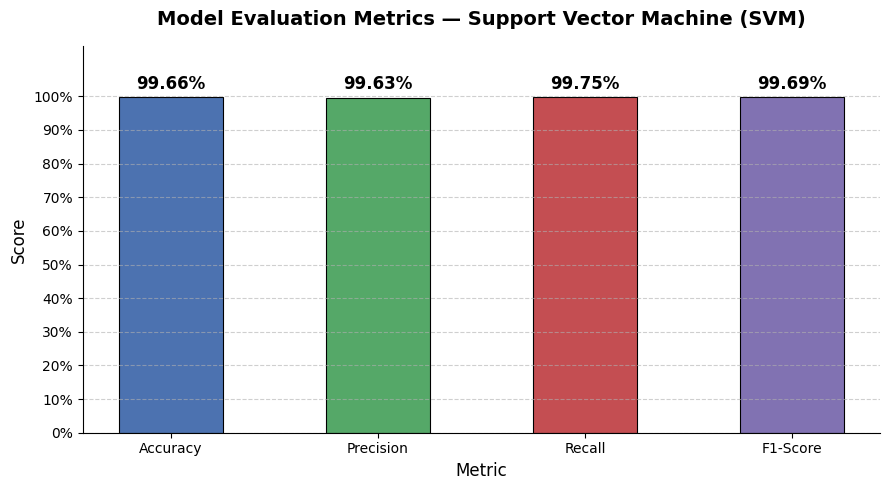

In [29]:
# ============================================================
# STAGE 5 — Evaluation: Metrics Bar Chart
# - Visualises Accuracy, Precision, Recall and F1-Score side by side
# - Each bar is annotated with the exact percentage value
# - Makes it easy to compare all four metrics at a glance
# ============================================================

import matplotlib.pyplot as plt
import numpy as np

metrics_names  = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]
bar_colors     = ['#4C72B0', '#55A868', '#C44E52', '#8172B2']

fig, ax = plt.subplots(figsize=(9, 5))

bars = ax.bar(metrics_names, metrics_values, color=bar_colors,
              width=0.5, edgecolor='black', linewidth=0.8)

# Annotate each bar with its percentage value
for bar, val in zip(bars, metrics_values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.012,
        f"{val * 100:.2f}%",
        ha='center', va='bottom', fontsize=12, fontweight='bold'
    )

ax.set_title('Model Evaluation Metrics — Support Vector Machine (SVM)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_ylabel('Score', fontsize=12)
ax.set_xlabel('Metric', fontsize=12)
ax.set_ylim(0, 1.15)
ax.set_yticks(np.arange(0, 1.1, 0.1))
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.grid(axis='y', linestyle='--', alpha=0.6)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()

In [30]:
# ============================================================
# STAGE 5 — Evaluation: Confusion Matrix Summary Table
# - True Negative  (TN): Ham emails correctly identified
# - False Positive (FP): Ham emails wrongly flagged as Spam
# - False Negative (FN): Spam emails missed by the model
# - True Positive  (TP): Spam emails correctly detected
# ============================================================

import pandas as pd
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()

# Build the confusion matrix summary table
cm_summary = pd.DataFrame({
    'Term'           : [
        'True Negative  (TN)',
        'False Positive (FP)',
        'False Negative (FN)',
        'True Positive  (TP)',
        'Total Test Emails'
    ],
    'Meaning'        : [
        'Ham emails correctly predicted as Ham',
        'Ham emails incorrectly predicted as Spam',
        'Spam emails incorrectly predicted as Ham',
        'Spam emails correctly predicted as Spam',
        'All emails evaluated in the test set'
    ],
    'Count'          : [TN, FP, FN, TP, TN + FP + FN + TP],
    'Percentage (%)' : [
        f"{TN / (TN+FP+FN+TP) * 100:.2f}%",
        f"{FP / (TN+FP+FN+TP) * 100:.2f}%",
        f"{FN / (TN+FP+FN+TP) * 100:.2f}%",
        f"{TP / (TN+FP+FN+TP) * 100:.2f}%",
        "100.00%"
    ]
})

cm_summary

,Term,Meaning,Count,Percentage (%)
0,True Negative (TN),Ham emails correctly predicted as Ham,3446,44.00%
1,False Positive (FP),Ham emails incorrectly predicted as Spam,16,0.20%
2,False Negative (FN),Spam emails incorrectly predicted as Ham,11,0.14%
3,True Positive (TP),Spam emails correctly predicted as Spam,4358,55.65%
4,Total Test Emails,All emails evaluated in the test set,7831,100.00%


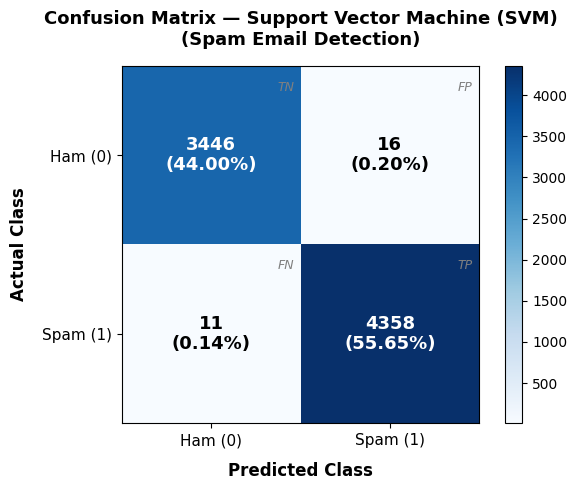

In [31]:
# ============================================================
# STAGE 5 — Evaluation: Confusion Matrix Heatmap
# - Rows represent the Actual class (what the email truly is)
# - Columns represent the Predicted class (what the model said)
# - Each cell shows the count and its percentage of total test emails
# - Green diagonal = correct predictions; Red off-diagonal = errors
# ============================================================

import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix

# Recompute confusion matrix
cm     = confusion_matrix(y_test, y_pred)
total  = cm.sum()
labels = ['Ham (0)', 'Spam (1)']

fig, ax = plt.subplots(figsize=(7, 5))

# Draw the heatmap manually for full control over styling
im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

# Annotate each cell with count and percentage
thresh = cm.max() / 2.0
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        count   = cm[i, j]
        percent = count / total * 100
        color   = 'white' if count > thresh else 'black'
        ax.text(j, i,
                f"{count}\n({percent:.2f}%)",
                ha='center', va='center',
                fontsize=13, fontweight='bold', color=color)

# Axis labels and ticks
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(labels, fontsize=11)
ax.set_yticklabels(labels, fontsize=11)
ax.set_xlabel('Predicted Class', fontsize=12, fontweight='bold', labelpad=10)
ax.set_ylabel('Actual Class',    fontsize=12, fontweight='bold', labelpad=10)
ax.set_title('Confusion Matrix — Support Vector Machine (SVM)\n(Spam Email Detection)',
             fontsize=13, fontweight='bold', pad=15)

# Add TN / FP / FN / TP corner labels
corner_labels = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        ax.text(j + 0.42, i - 0.38, corner_labels[i][j],
                ha='center', va='center',
                fontsize=9, color='grey', style='italic')

plt.tight_layout()
plt.show()

In [32]:
# ============================================================
# STAGE 5 — Step 4: Predict Using Custom Email Text (User Input)
# - Enter any email text in the 'custom_email' variable below
# - The same preprocessing pipeline is applied to the custom input
# - The trained model then predicts: Spam Email or Ham Email
# - Only the predicted class is displayed (Spam or Ham)
# ============================================================

import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import PorterStemmer, WordNetLemmatizer

# Ensure all required NLTK resources are available
nltk.download('stopwords',                    quiet=True)
nltk.download('punkt',                        quiet=True)
nltk.download('punkt_tab',                    quiet=True)
nltk.download('wordnet',                      quiet=True)
nltk.download('omw-1.4',                      quiet=True)

# -------------------------------------------------------
# >>> ENTER YOUR CUSTOM EMAIL TEXT HERE <<<
# -------------------------------------------------------
custom_email = """
Congratulations! You have been selected as the lucky winner of our exclusive
lottery draw. You have won $1,000,000. To claim your prize, click the link
below and provide your bank account number and personal details immediately.
This offer expires in 24 hours. Act now!
"""

# -------------------------------------------------------
# Apply the identical preprocessing pipeline used during training
# -------------------------------------------------------

# Step 1: Remove HTML tags
text = re.sub(r'<[^>]+>', ' ', custom_email)

# Step 2: Remove URLs
text = re.sub(r'https?://\S+|www\.\S+', ' ', text)

# Step 3: Remove email addresses
text = re.sub(r'\b[\w.+-]+@[\w.-]+\.\w+\b', ' ', text)

# Step 4: Remove punctuation
text = re.sub(r'[^\w\s]', ' ', text)

# Step 5: Remove numbers
text = re.sub(r'\d+', ' ', text)

# Step 6: Remove special characters (keep only letters and spaces)
text = re.sub(r'[^a-zA-Z\s]', ' ', text)

# Step 7: Remove extra whitespace
text = re.sub(r'\s+', ' ', text).strip()

# Step 8: Convert to lowercase
text = text.lower()

# Step 9: Remove stop words
stop_words = set(stopwords.words('english'))
words = [w for w in text.split() if w not in stop_words]
text  = ' '.join(words)

# Step 10: Tokenize
tokens = word_tokenize(text)

# Step 11: Stemming with Porter Stemmer
stemmer = PorterStemmer()
tokens  = [stemmer.stem(w) for w in tokens]

# Step 12: Lemmatization with WordNet Lemmatizer
lemmatizer = WordNetLemmatizer()
tokens     = [lemmatizer.lemmatize(w) for w in tokens]

# Join final tokens into a clean processed string
processed_custom_email = ' '.join(tokens)

# -------------------------------------------------------
# Transform the processed custom email using the fitted TF-IDF vectorizer
# -------------------------------------------------------
custom_vector = tfidf_vectorizer.transform([processed_custom_email])

# -------------------------------------------------------
# Predict using the trained Support Vector Machine model
# -------------------------------------------------------
prediction = svm_model.predict(custom_vector)

# Map numeric prediction to human-readable class label
predicted_class = 'Spam Email' if prediction[0] == 1 else 'Ham Email'

# -------------------------------------------------------
# Display only the predicted class — pipeline ends here
# -------------------------------------------------------
print("=" * 50)
print("       EMAIL CLASSIFICATION RESULT")
print("=" * 50)
print(f"\n  Predicted Class : {predicted_class}")
print("\n" + "=" * 50)

       EMAIL CLASSIFICATION RESULT

  Predicted Class : Spam Email

